# OfficeAgentEnv RL Training Notebook (Single-File Submission)

This notebook is designed for **one-file Colab submission**.
It includes:
- Environment simulation
- Optional Enron spam data augmentation
- RL-style training (contextual bandit)
- Baseline vs trained evaluation
- Exportable submission artifacts

Run all cells top-to-bottom.

In [1]:
# Install dependencies (Colab)
%pip -q install datasets numpy pandas matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
import os
import random
from dataclasses import dataclass
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TASKS = ["easy", "medium", "hard"]
MAX_STEPS = {"easy": 10, "medium": 15, "hard": 12}
ACTIONS = ["classify_email", "reply_email", "schedule_meeting", "ignore_email"]
CATEGORIES = ["meeting_request", "urgent_task", "spam", "general_query"]

print("Setup complete.")

c:\Users\sriab\OneDrive\Desktop\Projects\OfficeAgentEnv\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [3]:
# -----------------------------
# 1) Environment + Data
# -----------------------------
@dataclass
class Email:
    email_id: str
    sender: str
    subject: str
    body: str
    timestamp: str
    category: str


BASE_EMAILS = [
    Email("e001", "alice@corp.com", "Request: 30-minute roadmap alignment this Thursday", "Could we schedule 30 minutes this Thursday at 3:00 PM to review Q3 roadmap?", "2024-07-01 09:00", "meeting_request"),
    Email("e002", "bob@spam.net", "Congratulations! Claim your $1000 gift card now", "Limited offer. Click to claim your reward immediately.", "2024-07-01 09:05", "spam"),
    Email("e003", "ceo@corp.com", "URGENT: Production API outage impacting customers", "Production API is failing with 500s. Immediate action required.", "2024-07-01 09:10", "urgent_task"),
    Email("e004", "diana@partner.org", "Question: OAuth 2.0 support in partner API", "Can you confirm OAuth client credentials support and docs?", "2024-07-01 09:15", "general_query"),
    Email("e005", "hr@corp.com", "Schedule update: Engineering standup moved to 10:00 AM", "Please update calendar. Standup moved to 10:00 AM.", "2024-07-01 09:20", "meeting_request"),
]

RANDOM_POOL = [
    ("Request: 15-minute sales pipeline review", "Can we schedule 15 minutes Friday afternoon?", "meeting_request", "mark@sales.com"),
    ("Limited-time software discount offer", "Flash deal. Click now for discount.", "spam", "promo@deals.io"),
    ("CRITICAL: Failed overnight ETL", "ETL pipeline failed. Need immediate triage.", "urgent_task", "ops@corp.com"),
    ("Need access to shared dashboard", "Could you help with BI dashboard access?", "general_query", "ana@corp.com"),
    ("Please schedule customer check-in", "Can we schedule a customer call at 2:00 PM?", "meeting_request", "csm@corp.com"),
]

def parse_dt(s: str) -> Optional[datetime]:
    for fmt in ("%Y-%m-%d %H:%M", "%Y-%m-%dT%H:%M"):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    return None


def has_conflict(events: List[Tuple[str, str]], start: str, end: str) -> bool:
    ns = parse_dt(start)
    ne = parse_dt(end)
    if ns is None or ne is None:
        return False
    for evs, eve in events:
        s = parse_dt(evs)
        e = parse_dt(eve)
        if s is None or e is None:
            continue
        if ns < e and ne > s:
            return True
    return False


def first_free_slot(events: List[Tuple[str, str]], minutes: int = 30) -> Tuple[str, str]:
    cursor = datetime(2024, 7, 1, 9, 0)
    end_scan = datetime(2024, 7, 1, 17, 30)
    while cursor <= end_scan:
        end_dt = cursor + timedelta(minutes=minutes)
        ss = cursor.strftime("%Y-%m-%d %H:%M")
        ee = end_dt.strftime("%Y-%m-%d %H:%M")
        if not has_conflict(events, ss, ee):
            return ss, ee
        cursor += timedelta(minutes=30)
    fallback = datetime(2024, 7, 1, 17, 0)
    return fallback.strftime("%Y-%m-%d %H:%M"), (fallback + timedelta(minutes=30)).strftime("%Y-%m-%d %H:%M")


def build_episode_emails(task: str, enron_spam_samples: Optional[List[str]] = None) -> List[Email]:
    emails = [Email(**vars(e)) for e in BASE_EMAILS]

    extra_n = {"easy": 0, "medium": 2, "hard": 4}[task]
    for i in range(extra_n):
        subj, body, cat, sender = random.choice(RANDOM_POOL)
        emails.append(
            Email(
                email_id=f"x{i:03d}",
                sender=sender,
                subject=subj,
                body=body,
                timestamp="2024-07-01 10:00",
                category=cat,
            )
        )

    if enron_spam_samples:
        k = 2 if task == "hard" else 1
        for j, spam_text in enumerate(random.sample(enron_spam_samples, min(k, len(enron_spam_samples)))):
            emails.append(
                Email(
                    email_id=f"enron_spam_{j}",
                    sender="unknown@external.com",
                    subject="External offer",
                    body=spam_text[:240],
                    timestamp="2024-07-01 10:30",
                    category="spam",
                )
            )

    random.shuffle(emails)
    return emails


class ExecAssistSim:
    def __init__(self, task: str, seed: int = 42, enron_spam_samples: Optional[List[str]] = None):
        random.seed(seed)
        self.task = task
        self.max_steps = MAX_STEPS[task]
        self.step_count = 0
        self.pending = build_episode_emails(task, enron_spam_samples=enron_spam_samples)
        self.processed = []
        self.calendar = [("2024-07-01 10:00", "2024-07-01 10:30"), ("2024-07-01 14:00", "2024-07-01 15:00")]
        self.total_reward = 0.0

    def observation(self) -> Dict:
        return {
            "task_name": self.task,
            "current_step": self.step_count,
            "pending_emails": [vars(e) for e in self.pending],
            "processed_count": len(self.processed),
            "calendar_events": [{"start_time": s, "end_time": e} for s, e in self.calendar],
        }

    def step(self, action: Dict) -> Tuple[Dict, float, bool, Dict]:
        self.step_count += 1
        reward = -0.02
        info = {}

        if not self.pending:
            done = True
            return self.observation(), reward, done, info

        target_id = action.get("email_id")
        idx = next((i for i, e in enumerate(self.pending) if e.email_id == target_id), None)
        if idx is None:
            reward -= 0.10
            done = self.step_count >= self.max_steps
            return self.observation(), reward, done, {"error": "invalid_email_id"}

        email = self.pending.pop(idx)
        self.processed.append(email.email_id)

        action_type = action.get("action_type")
        true_cat = email.category

        if action_type == "classify_email":
            pred_cat = action.get("category", "general_query")
            reward += 0.30 if pred_cat == true_cat else -0.20

        elif action_type == "reply_email":
            txt = str(action.get("reply_text", "")).strip()
            if true_cat == "general_query" and len(txt) >= 20:
                reward += 0.20
            else:
                reward += -0.10

        elif action_type == "schedule_meeting":
            s = action.get("meeting_start_time", "")
            e = action.get("meeting_end_time", "")
            if true_cat != "meeting_request":
                reward += -0.20
            elif has_conflict(self.calendar, s, e):
                reward += -0.25
            else:
                reward += 0.30
                self.calendar.append((s, e))

        elif action_type == "ignore_email":
            if true_cat == "spam":
                reward += 0.10
            else:
                reward += -0.15

        else:
            reward += -0.10

        done = (self.step_count >= self.max_steps) or (len(self.pending) == 0)
        if done and len(self.pending) == 0:
            reward += 0.20

        self.total_reward += reward
        return self.observation(), reward, done, info


print("Environment defined.")

Environment defined.


In [4]:
# -----------------------------
# 2) Optional Enron augmentation
# -----------------------------
def load_enron_spam_samples(max_rows: int = 400) -> List[str]:
    """Loads spam-like text from a public Enron-derived dataset.
    Falls back gracefully if unavailable.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset("SetFit/enron_spam", split="train")
        spam_texts = [x["text"] for x in ds if int(x["label"]) == 1]
        random.shuffle(spam_texts)
        return spam_texts[:max_rows]
    except Exception as exc:
        print(f"[WARN] Enron load failed ({exc}). Using synthetic-only training.")
        return []

ENRON_SPAM = load_enron_spam_samples(max_rows=300)
print(f"Loaded Enron spam samples: {len(ENRON_SPAM)}")

[WARN] Enron load failed (Dataset 'SetFit/enron_spam' doesn't exist on the Hub or cannot be accessed.). Using synthetic-only training.
Loaded Enron spam samples: 0


In [5]:
# -----------------------------
# 3) Policies: baseline + RL bandit
# -----------------------------
def estimate_action_confidence(email: Dict) -> Dict[str, float]:
    text = (email.get("subject", "") + " " + email.get("body", "")).lower()
    conf = {
        "schedule_meeting": 0.15,
        "ignore_email": 0.10,
        "reply_email": 0.12,
        "classify_email": 0.10,
    }

    conf["schedule_meeting"] += 0.18 * sum(w in text for w in ["meeting", "schedule", "call", "discuss", "standup"])
    conf["ignore_email"] += 0.20 * sum(w in text for w in ["free", "offer", "prize", "claim", "discount", "click"])
    conf["reply_email"] += 0.16 * sum(w in text for w in ["?", "can you", "could you", "help", "question"])
    conf["classify_email"] += 0.22 * sum(w in text for w in ["urgent", "critical", "immediate", "outage", "failure"])
    return conf


def infer_category(email: Dict) -> str:
    text = (email.get("subject", "") + " " + email.get("body", "")).lower()
    if any(w in text for w in ["meeting", "schedule", "calendar", "standup"]):
        return "meeting_request"
    if any(w in text for w in ["urgent", "asap", "critical", "outage", "failure"]):
        return "urgent_task"
    if any(w in text for w in ["offer", "win", "gift", "inheritance", "prize", "discount"]):
        return "spam"
    return "general_query"


def build_action(email: Dict, action_type: str, calendar_events: List[Dict]) -> Dict:
    eid = email["email_id"]
    if action_type == "schedule_meeting":
        ev_pairs = [(x["start_time"], x["end_time"]) for x in calendar_events]
        st, et = first_free_slot(ev_pairs, minutes=30)
        return {
            "action_type": "schedule_meeting",
            "email_id": eid,
            "meeting_title": email.get("subject", "Meeting"),
            "meeting_start_time": st,
            "meeting_end_time": et,
            "participants": [email.get("sender", "unknown@example.com")],
        }
    if action_type == "ignore_email":
        return {"action_type": "ignore_email", "email_id": eid}
    if action_type == "reply_email":
        return {
            "action_type": "reply_email",
            "email_id": eid,
            "reply_text": "Thanks for your email. I reviewed your request and will follow up with details shortly.",
        }
    return {
        "action_type": "classify_email",
        "email_id": eid,
        "category": infer_category(email),
    }


class BaselinePolicy:
    def act(self, obs: Dict, step: int) -> Dict:
        if not obs["pending_emails"]:
            return {"action_type": "ignore_email", "email_id": "none"}
        email = obs["pending_emails"][0]
        conf = estimate_action_confidence(email)
        action_type = max(conf, key=conf.get)
        return build_action(email, action_type, obs["calendar_events"])


class ContextualBanditPolicy:
    def __init__(self):
        self.q = {a: 0.0 for a in ACTIONS}
        self.n = {a: 0 for a in ACTIONS}

    def epsilon(self, task: str, step: int) -> float:
        base = {"easy": 0.08, "medium": 0.15, "hard": 0.22}.get(task, 0.12)
        return max(0.05, base * (0.93 ** max(step - 1, 0)))

    def score(self, action: str, confidence: float) -> float:
        return confidence + 0.35 * self.q[action]

    def update(self, action: str, reward: float):
        self.n[action] += 1
        old = self.q[action]
        self.q[action] = old + (reward - old) / self.n[action]

    def act(self, obs: Dict, step: int) -> Dict:
        if not obs["pending_emails"]:
            return {"action_type": "ignore_email", "email_id": "none"}

        email = obs["pending_emails"][0]
        conf = estimate_action_confidence(email)
        task = obs.get("task_name", "medium")

        scores = {a: self.score(a, conf[a]) for a in ACTIONS}
        chosen = max(scores, key=scores.get)

        if random.random() < self.epsilon(task, step):
            chosen = random.choice(ACTIONS)

        return build_action(email, chosen, obs["calendar_events"])


print("Policies ready.")

Policies ready.


In [6]:
# -----------------------------
# 4) Train RL policy
# -----------------------------
def run_episode(task: str, policy, seed: int, enron_spam_samples: Optional[List[str]] = None, train: bool = False):
    env = ExecAssistSim(task=task, seed=seed, enron_spam_samples=enron_spam_samples)
    obs = env.observation()
    done = False
    step = 0

    while not done and step < MAX_STEPS[task]:
        step += 1
        action = policy.act(obs, step)
        obs2, reward, done, _ = env.step(action)
        if train and hasattr(policy, "update"):
            policy.update(action.get("action_type", "classify_email"), reward)
        obs = obs2

    return env.total_reward, step


TRAIN_EPISODES = 350
TRAIN_TASK_MIX = ["easy", "medium", "hard"]

bandit = ContextualBanditPolicy()
history = []

for ep in tqdm(range(TRAIN_EPISODES), desc="Training"):
    task = random.choice(TRAIN_TASK_MIX)
    rew, steps = run_episode(task, bandit, seed=SEED + ep, enron_spam_samples=ENRON_SPAM, train=True)
    history.append({"episode": ep + 1, "task": task, "reward": rew, "steps": steps})

hist_df = pd.DataFrame(history)
print("Training done. Learned Q-values:")
print(json.dumps(bandit.q, indent=2))

Training: 100%|██████████| 350/350 [00:00<00:00, 1072.33it/s]

Training done. Learned Q-values:
{
  "classify_email": 0.3039520958083831,
  "reply_email": 0.17637096774193534,
  "schedule_meeting": 0.288245243128964,
  "ignore_email": 0.07649298597194384
}


,baseline_reward,rl_reward,delta
task,,,
easy,1.300,1.244,-0.056
hard,2.172,1.854,-0.318
medium,1.728,1.559,-0.169


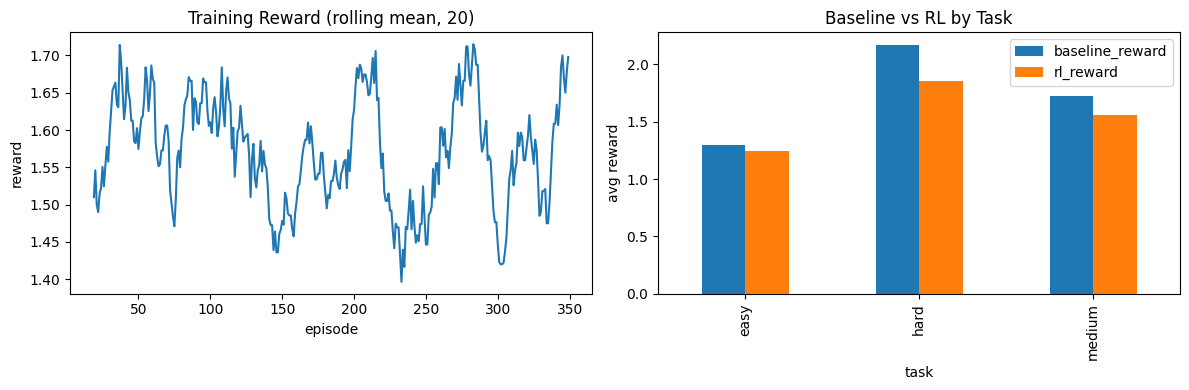

In [7]:
# -----------------------------
# 5) Evaluate baseline vs trained
# -----------------------------
def evaluate_policy(policy, episodes_per_task: int = 80, enron_spam_samples: Optional[List[str]] = None):
    rows = []
    for task in TASKS:
        for ep in range(episodes_per_task):
            rew, steps = run_episode(task, policy, seed=10000 + ep, enron_spam_samples=enron_spam_samples, train=False)
            rows.append({"task": task, "reward": rew, "steps": steps})
    return pd.DataFrame(rows)


baseline = BaselinePolicy()
base_df = evaluate_policy(baseline, episodes_per_task=60, enron_spam_samples=ENRON_SPAM)
rl_df = evaluate_policy(bandit, episodes_per_task=60, enron_spam_samples=ENRON_SPAM)

summary = pd.DataFrame({
    "baseline_reward": base_df.groupby("task")["reward"].mean(),
    "rl_reward": rl_df.groupby("task")["reward"].mean(),
})
summary["delta"] = summary["rl_reward"] - summary["baseline_reward"]
display(summary.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hist_df["reward"].rolling(20).mean().plot(ax=ax[0], title="Training Reward (rolling mean, 20)")
ax[0].set_xlabel("episode")
ax[0].set_ylabel("reward")

summary[["baseline_reward", "rl_reward"]].plot(kind="bar", ax=ax[1], title="Baseline vs RL by Task")
ax[1].set_ylabel("avg reward")
plt.tight_layout()
plt.show()

In [8]:
# -----------------------------
# 6) Export submission artifacts
# -----------------------------
os.makedirs("/content/submission", exist_ok=True)
policy_path = "/content/submission/rl_bandit_policy.json"
with open(policy_path, "w", encoding="utf-8") as f:
    json.dump({"q_values": bandit.q, "counts": bandit.n, "seed": SEED}, f, indent=2)

inference_script = '''
import json
import random
from typing import Dict

ACTIONS = ["classify_email", "reply_email", "schedule_meeting", "ignore_email"]


def estimate_action_confidence(email: Dict) -> Dict[str, float]:
    text = (email.get("subject", "") + " " + email.get("body", "")).lower()
    conf = {"schedule_meeting": 0.15, "ignore_email": 0.10, "reply_email": 0.12, "classify_email": 0.10}
    conf["schedule_meeting"] += 0.18 * sum(w in text for w in ["meeting", "schedule", "call", "discuss", "standup"])
    conf["ignore_email"] += 0.20 * sum(w in text for w in ["free", "offer", "prize", "claim", "discount", "click"])
    conf["reply_email"] += 0.16 * sum(w in text for w in ["?", "can you", "could you", "help", "question"])
    conf["classify_email"] += 0.22 * sum(w in text for w in ["urgent", "critical", "immediate", "outage", "failure"])
    return conf


def infer_category(email: Dict) -> str:
    text = (email.get("subject", "") + " " + email.get("body", "")).lower()
    if any(w in text for w in ["meeting", "schedule", "calendar", "standup"]):
        return "meeting_request"
    if any(w in text for w in ["urgent", "asap", "critical", "outage", "failure"]):
        return "urgent_task"
    if any(w in text for w in ["offer", "win", "gift", "inheritance", "prize", "discount"]):
        return "spam"
    return "general_query"


def choose_action(obs: Dict, q_values: Dict[str, float]):
    pending = obs.get("pending_emails", [])
    if not pending:
        return {"action_type": "ignore_email", "email_id": "none"}

    email = pending[0]
    conf = estimate_action_confidence(email)
    scores = {a: conf[a] + 0.35 * q_values.get(a, 0.0) for a in ACTIONS}
    action_type = max(scores, key=scores.get)

    if action_type == "schedule_meeting":
        return {
            "action_type": "schedule_meeting",
            "email_id": email["email_id"],
            "meeting_title": email.get("subject", "Meeting"),
            "meeting_start_time": "2024-07-01 16:00",
            "meeting_end_time": "2024-07-01 16:30",
            "participants": [email.get("sender", "unknown@example.com")],
        }
    if action_type == "ignore_email":
        return {"action_type": "ignore_email", "email_id": email["email_id"]}
    if action_type == "reply_email":
        return {"action_type": "reply_email", "email_id": email["email_id"], "reply_text": "Thank you for your message. I will follow up shortly with next steps."}
    return {"action_type": "classify_email", "email_id": email["email_id"], "category": infer_category(email)}


if __name__ == "__main__":
    with open("rl_bandit_policy.json", "r", encoding="utf-8") as f:
        policy = json.load(f)
    print("Loaded policy q-values:", policy.get("q_values", {}))
'''

with open("/content/submission/inference_submission.py", "w", encoding="utf-8") as f:
    f.write(inference_script)

print("Artifacts written:")
print("-", policy_path)
print("- /content/submission/inference_submission.py")

Artifacts written:
- /content/submission/rl_bandit_policy.json
- /content/submission/inference_submission.py


In [9]:
# Optional: package everything as a zip for easy submission upload/download
import shutil
zip_path = "/content/officeagent_rl_submission"
shutil.make_archive(zip_path, "zip", "/content/submission")
print(zip_path + ".zip")

/content/officeagent_rl_submission.zip
